# CSCE 40103 Module 3, Lecture 2 Code Notebook

## Turning Messages Into Model Evidence

This notebook supports the second Module 3 lecture. It shows how text becomes numbers, how Bag-of-Words and TF-IDF work, and how to train a simple Naive Bayes spam classifier.

## Dataset note

This notebook uses a small classroom dataset created for teaching. The labels are `ham` and `spam`.

A ham/spam classifier is not automatically a true phishing detector. A true phishing detector needs phishing-labeled examples.

## 1. Import packages

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

## 2. Create the classroom dataset

In [3]:
import pandas as pd

# Small classroom dataset created for this module.
# Labels are ham/spam, not true phishing labels.
data = [
    # Ham / legitimate messages
    {"text": "Reminder your project notebook is due Friday on Blackboard", "label": "ham"},
    {"text": "The review session for exam two is tomorrow afternoon", "label": "ham"},
    {"text": "Please submit your lab report through the course website", "label": "ham"},
    {"text": "Office hours are moved to Thursday morning", "label": "ham"},
    {"text": "Your scholarship form is due today through the official portal", "label": "ham"},
    {"text": "Free tutoring is available before the final exam", "label": "ham"},
    {"text": "The department seminar will meet in room 204", "label": "ham"},
    {"text": "Your advisor approved the course registration request", "label": "ham"},
    {"text": "Class is cancelled today because of weather", "label": "ham"},
    {"text": "Please check Blackboard for the updated assignment rubric", "label": "ham"},
    {"text": "The library workshop on research databases starts at noon", "label": "ham"},
    {"text": "Your team meeting has been moved to 3 pm", "label": "ham"},
    {"text": "Campus parking permits are available through the official university portal", "label": "ham"},
    {"text": "Submit your final project proposal by Sunday evening", "label": "ham"},
    {"text": "The professor posted feedback on your notebook submission", "label": "ham"},
    {"text": "Your payroll document is available in the official employee portal", "label": "ham"},
    {"text": "The student success center offers free math help this week", "label": "ham"},
    {"text": "Please review the updated syllabus before class", "label": "ham"},
    {"text": "Your course evaluation survey is now open", "label": "ham"},
    {"text": "Reminder the lab starts at 9 15 tomorrow morning", "label": "ham"},
    {"text": "The official IT help desk will perform maintenance tonight", "label": "ham"},
    {"text": "Your advising appointment is confirmed for Monday", "label": "ham"},
    {"text": "The university portal password reset page is available from the official website", "label": "ham"},
    {"text": "Please bring your laptop to the next class meeting", "label": "ham"},
    {"text": "The research talk slides are posted on the class page", "label": "ham"},
    {"text": "Your financial aid checklist has been updated in the official student portal", "label": "ham"},
    {"text": "The quiz deadline is tonight and the link is on Blackboard", "label": "ham"},
    {"text": "Use the university portal to confirm your emergency contact information", "label": "ham"},
    {"text": "The tutoring center is offering free Python review sessions", "label": "ham"},
    {"text": "Your lab grade has been released in the learning system", "label": "ham"},
    # Spam / suspicious messages
    {"text": "Congratulations you won a free prize click now", "label": "spam"},
    {"text": "Claim your free gift card today", "label": "spam"},
    {"text": "Your account will expire today verify your password now", "label": "spam"},
    {"text": "Urgent action required login to confirm your access", "label": "spam"},
    {"text": "You have been selected for a cash reward claim immediately", "label": "spam"},
    {"text": "Your mailbox storage is full update your account settings now", "label": "spam"},
    {"text": "Verify your payment profile to receive your refund", "label": "spam"},
    {"text": "Click this link to unlock your suspended account", "label": "spam"},
    {"text": "Limited time offer claim your prize before midnight", "label": "spam"},
    {"text": "Your password expires today confirm your login details", "label": "spam"},
    {"text": "Act now to avoid account deletion", "label": "spam"},
    {"text": "You won an exclusive reward open this message now", "label": "spam"},
    {"text": "Your bank account requires immediate verification", "label": "spam"},
    {"text": "Suspicious login detected verify your identity immediately", "label": "spam"},
    {"text": "Your package delivery failed click to reschedule", "label": "spam"},
    {"text": "Free vacation offer claim your ticket now", "label": "spam"},
    {"text": "Update your account access profile today", "label": "spam"},
    {"text": "Important notice your account has been disabled", "label": "spam"},
    {"text": "Click now for a free loan approval", "label": "spam"},
    {"text": "Confirm your password to keep your mailbox active", "label": "spam"},
    {"text": "Your payment failed update card details immediately", "label": "spam"},
    {"text": "You are eligible for a refund confirm your details", "label": "spam"},
    {"text": "Final warning verify account ownership now", "label": "spam"},
    {"text": "Prize winner confirmation required click to claim", "label": "spam"},
    {"text": "Your account access will be suspended unless you review now", "label": "spam"},
    {"text": "Security alert login from unknown device confirm access", "label": "spam"},
    {"text": "Free money transfer offer available today", "label": "spam"},
    {"text": "Immediate response required to restore your account", "label": "spam"},
    {"text": "Confirm your login at the account review page", "label": "spam"},
    {"text": "Urgent account verification needed before midnight", "label": "spam"},
]

df = pd.DataFrame(data)
print("Dataset shape:", df.shape)
display(df.head())
print("Class counts:")
print(df["label"].value_counts())

Dataset shape: (60, 2)


,text,label
0,Reminder your project notebook is due Friday o...,ham
1,The review session for exam two is tomorrow af...,ham
2,Please submit your lab report through the cour...,ham
3,Office hours are moved to Thursday morning,ham
4,Your scholarship form is due today through the...,ham


Class counts:
label
ham     30
spam    30
Name: count, dtype: int64


## 3. Tokenization by hand

Tokenization means splitting text into pieces. Classical text models usually turn tokens into features.

In [4]:
message = "Verify your account now"

tokens = message.lower().split()
print("Original message:", message)
print("Tokens:", tokens)

Original message: Verify your account now
Tokens: ['verify', 'your', 'account', 'now']


## 4. Bag-of-Words with CountVectorizer

Bag-of-Words counts words. It ignores word order and keeps word frequency.

In [5]:
toy_messages = [
    "free prize now",
    "account review now",
    "project deadline"
]

count_vectorizer = CountVectorizer()
count_matrix = count_vectorizer.fit_transform(toy_messages)

count_df = pd.DataFrame(
    count_matrix.toarray(),
    columns=count_vectorizer.get_feature_names_out()
)

count_df.insert(0, "message", toy_messages)
display(count_df)

,message,account,deadline,free,now,prize,project,review
0,free prize now,0,0,1,1,1,0,0
1,account review now,1,0,0,1,0,0,1
2,project deadline,0,1,0,0,0,1,0


## 5. Activity: build a feature row by hand

Message: `Your account review is due today`

Vocabulary: `account`, `review`, `prize`, `deadline`, `today`

Expected row: account = 1, review = 1, prize = 0, deadline = 0, today = 1

In [6]:
activity_message = ["Your account review is due today"]
activity_vocabulary = ["account", "review", "prize", "deadline", "today"]

activity_vectorizer = CountVectorizer(vocabulary=activity_vocabulary)
activity_matrix = activity_vectorizer.transform(activity_message)

activity_df = pd.DataFrame(
    activity_matrix.toarray(),
    columns=activity_vectorizer.get_feature_names_out()
)
activity_df.insert(0, "message", activity_message)
display(activity_df)

,message,account,review,prize,deadline,today
0,Your account review is due today,1,1,0,0,1


## 6. TF-IDF

TF-IDF gives less weight to words that appear everywhere and more weight to words that are more informative in a document.

It still does not understand meaning or word order. It mainly improves word weighting.

In [7]:
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(toy_messages)

tfidf_df = pd.DataFrame(
    np.round(tfidf_matrix.toarray(), 3),
    columns=tfidf_vectorizer.get_feature_names_out()
)
tfidf_df.insert(0, "message", toy_messages)
display(tfidf_df)

,message,account,deadline,free,now,prize,project,review
0,free prize now,0.000,0.000,0.623,0.474,0.623,0.000,0.000
1,account review now,0.623,0.000,0.000,0.474,0.000,0.000,0.623
2,project deadline,0.000,0.707,0.000,0.000,0.000,0.707,0.000


## 7. scikit-learn tools used in this lecture

| Concept | scikit-learn tool |
|---|---|
| Bag-of-Words | `CountVectorizer` |
| TF-IDF | `TfidfVectorizer` |
| Text + model workflow | `Pipeline` |
| Naive Bayes classifier | `MultinomialNB` |

## 8. Train-test split

We split the data into a training set and a test set.

The model learns from the training set. We evaluate it on the test set.

In [8]:
X = df["text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

print("Training examples:", len(X_train))
print("Testing examples:", len(X_test))
print("Training label counts:")
print(y_train.value_counts())
print("Testing label counts:")
print(y_test.value_counts())

Training examples: 45
Testing examples: 15
Training label counts:
label
spam    23
ham     22
Name: count, dtype: int64
Testing label counts:
label
ham     8
spam    7
Name: count, dtype: int64


## 9. Avoid a common mistake: data leakage

Do not let the test set influence the vocabulary.

The correct process is:

1. Fit TF-IDF on training text only.
2. Transform test text using the training vocabulary.
3. Evaluate predictions on the test labels.

`Pipeline` helps keep this process clean.

## 10. Train Naive Bayes with TF-IDF

`MultinomialNB` is suitable for word-count style features. In practice, TF-IDF values can also work because they are nonnegative text features.

In [9]:
spam_detector = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english")),
    ("model", MultinomialNB(alpha=1.0))
])

spam_detector.fit(X_train, y_train)
print("Model trained successfully.")

Model trained successfully.


## 11. Evaluate the detector

              precision    recall  f1-score   support

         ham       1.00      0.75      0.86         8
        spam       0.78      1.00      0.88         7

    accuracy                           0.87        15
   macro avg       0.89      0.88      0.87        15
weighted avg       0.90      0.87      0.87        15



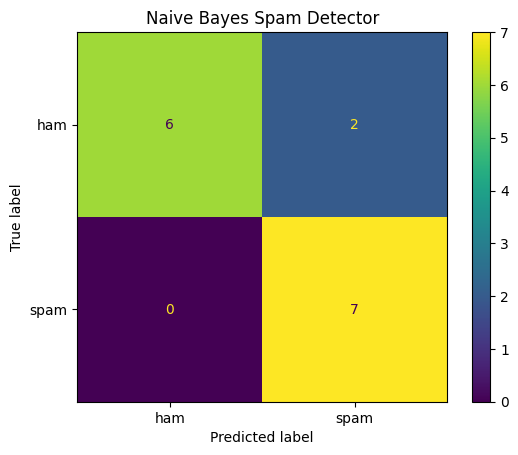

In [10]:
predictions = spam_detector.predict(X_test)

print(classification_report(y_test, predictions))

ConfusionMatrixDisplay.from_predictions(y_test, predictions)
plt.title("Naive Bayes Spam Detector")
plt.show()

## 12. Read the confusion matrix with code

In [11]:
labels = ["ham", "spam"]
cm = confusion_matrix(y_test, predictions, labels=labels)
cm_df = pd.DataFrame(cm, index=[f"Actual {x}" for x in labels], columns=[f"Predicted {x}" for x in labels])
display(cm_df)

actual_ham_pred_spam = cm_df.loc["Actual ham", "Predicted spam"]
actual_spam_pred_ham = cm_df.loc["Actual spam", "Predicted ham"]

print("Safe messages flagged as spam:", actual_ham_pred_spam)
print("Spam messages that reached inbox:", actual_spam_pred_ham)

,Predicted ham,Predicted spam
Actual ham,6,2
Actual spam,0,7


Safe messages flagged as spam: 2
Spam messages that reached inbox: 0


## 13. Inspect mistakes

Counting mistakes is not enough. Inspect the actual messages that were misclassified.

In [12]:
test_results = pd.DataFrame({
    "message": X_test.values,
    "true_label": y_test.values,
    "predicted_label": predictions
})

test_results["correct"] = test_results["true_label"] == test_results["predicted_label"]

mistakes = test_results[test_results["correct"] == False]
print("Number of mistakes:", len(mistakes))
display(mistakes)

Number of mistakes: 2


,message,true_label,predicted_label,correct
7,The department seminar will meet in room 204,ham,spam,False
13,Your course evaluation survey is now open,ham,spam,False


## 14. Test a few new classroom messages

These are not real phishing tests. They are safe examples for understanding model behavior.

In [13]:
new_messages = [
    "Free tutoring before the exam",
    "Free prize waiting for you click now",
    "Your account access will expire today review your profile now",
    "Reminder your lab notebook is due on Blackboard",
]

new_predictions = spam_detector.predict(new_messages)

for message, prediction in zip(new_messages, new_predictions):
    print(f"Message: {message}")
    print(f"Prediction: {prediction}")
    print()

Message: Free tutoring before the exam
Prediction: ham

Message: Free prize waiting for you click now
Prediction: spam

Message: Your account access will expire today review your profile now
Prediction: spam

Message: Reminder your lab notebook is due on Blackboard
Prediction: ham



## 15. Inspect words that push toward spam or ham

Naive Bayes is useful for teaching because we can inspect word evidence.

The code below compares word log-probabilities for spam and ham.

In [14]:
tfidf_step = spam_detector.named_steps["tfidf"]
model_step = spam_detector.named_steps["model"]

feature_names = tfidf_step.get_feature_names_out()
classes = model_step.classes_
print("Model classes:", classes)

# Identify class positions.
ham_index = list(classes).index("ham")
spam_index = list(classes).index("spam")

# Difference: positive values favor spam, negative values favor ham.
spam_minus_ham = model_step.feature_log_prob_[spam_index] - model_step.feature_log_prob_[ham_index]

word_scores = pd.DataFrame({
    "word": feature_names,
    "spam_minus_ham_score": spam_minus_ham
})

print("Words most associated with spam in this small dataset:")
display(word_scores.sort_values("spam_minus_ham_score", ascending=False).head(10))

print("Words most associated with ham in this small dataset:")
display(word_scores.sort_values("spam_minus_ham_score", ascending=True).head(10))

Model classes: ['ham' 'spam']
Words most associated with spam in this small dataset:


,word,spam_minus_ham_score
1,account,1.414344
139,verify,0.943606
22,claim,0.916139
0,access,0.830248
134,update,0.820889
24,click,0.804912
92,prize,0.777946
56,immediately,0.765158
65,mailbox,0.674656
93,profile,0.672449


Words most associated with ham in this small dataset:


,word,spam_minus_ham_score
90,portal,-1.062862
80,official,-0.989270
23,class,-0.977636
135,updated,-0.806979
13,blackboard,-0.783900
131,university,-0.727272
67,meeting,-0.677432
41,exam,-0.646310
59,lab,-0.640317
73,moved,-0.637566


## 16. Vectorizer settings to try

These settings matter in the lab and assignment.

- `stop_words="english"`: removes many common English words
- `ngram_range=(1, 2)`: includes single words and two-word phrases
- `min_df=2`: ignores words that appear in fewer than 2 messages
- `max_df=0.95`: ignores words that appear in more than 95% of messages

In [15]:
ngram_detector = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english", ngram_range=(1, 2), min_df=1)),
    ("model", MultinomialNB(alpha=1.0))
])

ngram_detector.fit(X_train, y_train)
ngram_predictions = ngram_detector.predict(X_test)

print(classification_report(y_test, ngram_predictions))

              precision    recall  f1-score   support

         ham       1.00      0.75      0.86         8
        spam       0.78      1.00      0.88         7

    accuracy                           0.87        15
   macro avg       0.89      0.88      0.87        15
weighted avg       0.90      0.87      0.87        15



## 17. Summary

In this notebook, you learned how to:

- turn raw messages into word features
- compare Bag-of-Words and TF-IDF
- train a Naive Bayes text classifier
- read a confusion matrix
- inspect mistakes and word evidence

The next notebook compares several detectors using the same pipeline.